In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

In [2]:
plt.style.use('/home/sergi_alcala/Matplotlib/style.mplstyle')

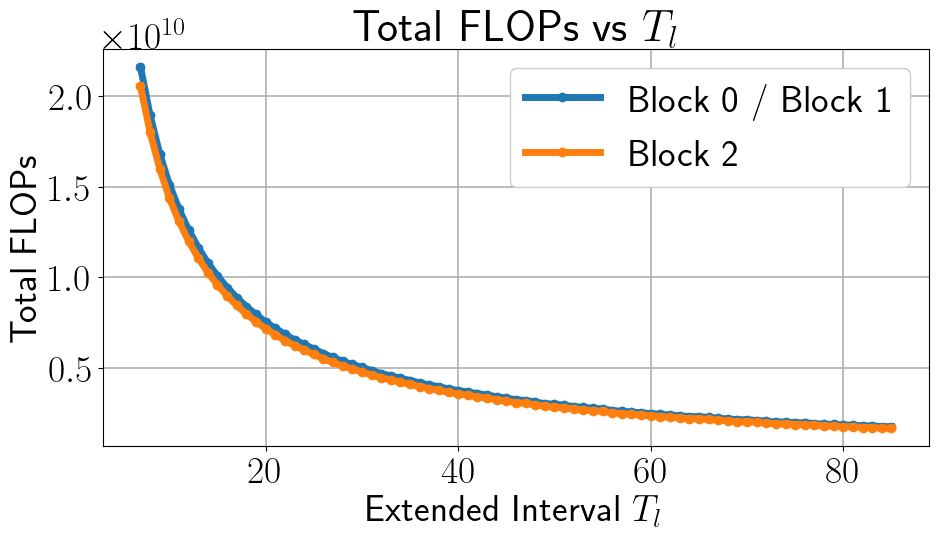

In [4]:


# Constants
TOTAL_TIMESTEPS = 3582
LOOKBACK = 6
FEATURES = 5
LSTM_UNITS = 128
DENSE1_UNITS = 64
OUTPUT_UNITS = 5
MC_PASSES = 100

def compute_flops_per_sample_block1(T, d, h, dense1, out):
    # LSTM FLOPs: T * (4dh + 4h^2 + 8h)
    lstm_flops = T * (4 * d * h + 4 * h**2 + 8 * h)
    # Dense + ReLU + Output layer FLOPs
    dense_flops = h * dense1 + dense1 + dense1 * out + out
    return lstm_flops + dense_flops

def compute_num_samples(total_timesteps, lookback, delay):
    usable_steps = total_timesteps - delay
    if usable_steps < lookback:
        return 0
    return (usable_steps - lookback) // delay + 1

flops_per_sample_block_1 = compute_flops_per_sample_block1(
    T=LOOKBACK,
    d=FEATURES,
    h=LSTM_UNITS,
    dense1=DENSE1_UNITS,
    out=OUTPUT_UNITS
)


# Example usage
lookback = 6
input_dim = 1
hidden_dim = 128
output_dim = 1

def compute_flops_per_sample_block2(T, d, h, d2):
    """
    Compute total FLOPs for make_model_lstm_block2.
    
    Args:
        T (int): Lookback (sequence length)
        d (int): Input dimension (features)
        h (int): LSTM hidden size
        d2 (int): Output size (final Dense layer)
        n_samples (int): Number of input sequences
        mc_passes (int): Number of Monte Carlo forward passes
        
    Returns:
        Total FLOPs (int)
    """
    # LSTM layer FLOPs
    flops_lstm = T * (4 * d * h + 4 * h ** 2 + 8 * h)
    
    # Dense layer FLOPs
    flops_dense = h * d2 + d2

    # Total per-sample
    flops_per_sample = flops_lstm + flops_dense

   
    return flops_per_sample

flops_per_sample_block_2 = compute_flops_per_sample_block2(
    T=lookback,
    d=input_dim,
    h=hidden_dim,
    d2=output_dim,
)

# Loop over DELAY values
delays = range(7, 86)
samples = []
flops_total_block1 = []
flops_total_block2 = []

for delay in delays:
    num_samples = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, delay)
    total_flops_block_1 = num_samples * flops_per_sample_block_1 * MC_PASSES
    total_flops_block_2 = num_samples * flops_per_sample_block_2 * MC_PASSES
    samples.append(num_samples)
    flops_total_block1.append(total_flops_block_1)
    flops_total_block2.append(total_flops_block_2)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(delays, flops_total_block1, marker='o', label='Block 0 / Block 1')
plt.plot(delays, flops_total_block2, marker='o', label='Block 2')
plt.legend()
plt.title(r'Total FLOPs vs $T_l$')
plt.xlabel(r'Extended Interval $T_l$')
plt.ylabel('Total FLOPs')
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
ROOT_DIR = ''
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [6]:
def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    test_length = len(bordeaux) - test_index_start
    return test_length

In [7]:
import os

Delay: 21 for phi 0.1 and eta 1
Total timesteps: 3561
Delay: 27 for phi 0.1 and eta 2
Total timesteps: 3555
Delay: 48 for phi 0.1 and eta 10
Total timesteps: 3534
Delay: 85 for phi 0.1 and eta 20
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 30
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 40
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 50
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 70
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 90
Total timesteps: 3497
Delay: 85 for phi 0.1 and eta 100
Total timesteps: 3497


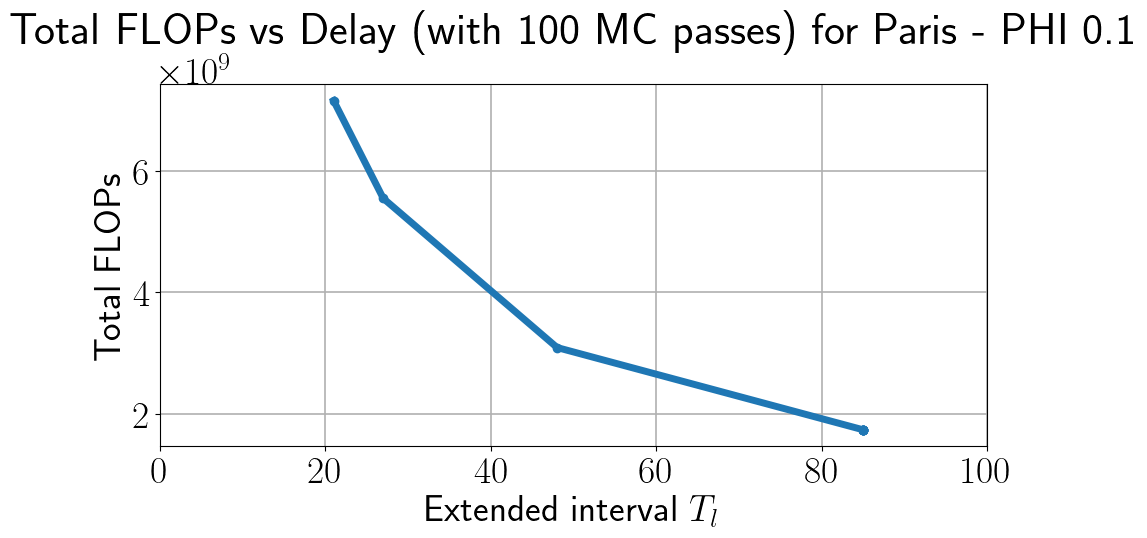

Delay: 21 for phi 0.5 and eta 1
Total timesteps: 3561
Delay: 21 for phi 0.5 and eta 2
Total timesteps: 3561
Delay: 21 for phi 0.5 and eta 10
Total timesteps: 3561
Delay: 35 for phi 0.5 and eta 20
Total timesteps: 3547
Delay: 35 for phi 0.5 and eta 30
Total timesteps: 3547
Delay: 85 for phi 0.5 and eta 40
Total timesteps: 3497
Delay: 85 for phi 0.5 and eta 50
Total timesteps: 3497
Delay: 85 for phi 0.5 and eta 70
Total timesteps: 3497
Delay: 85 for phi 0.5 and eta 90
Total timesteps: 3497
Delay: 85 for phi 0.5 and eta 100
Total timesteps: 3497


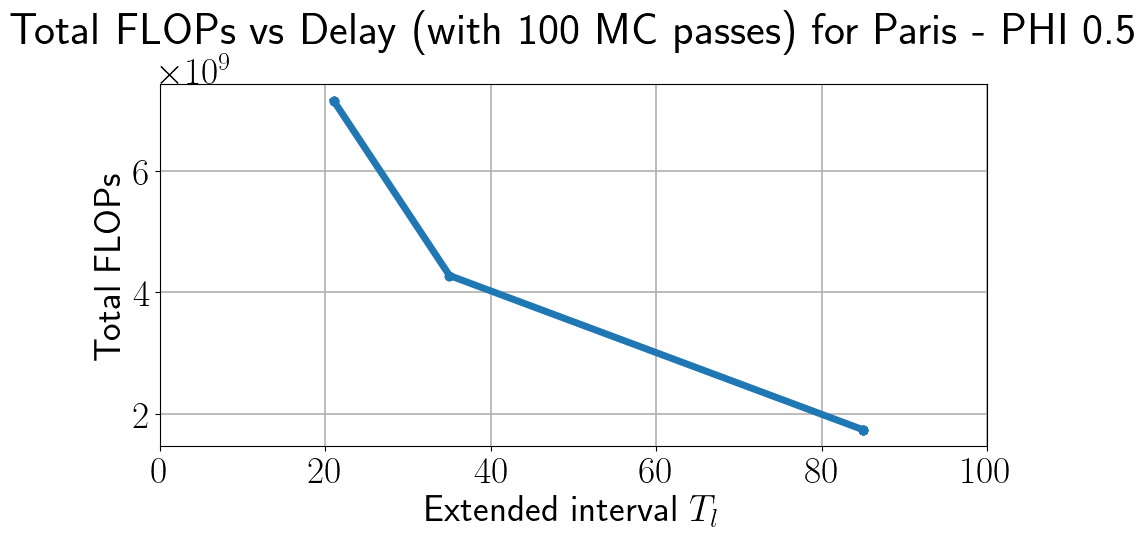

Delay: 7 for phi 1 and eta 1
Total timesteps: 3575
Delay: 21 for phi 1 and eta 2
Total timesteps: 3561
Delay: 21 for phi 1 and eta 10
Total timesteps: 3561
Delay: 33 for phi 1 and eta 20
Total timesteps: 3549
Delay: 35 for phi 1 and eta 30
Total timesteps: 3547
Delay: 48 for phi 1 and eta 40
Total timesteps: 3534
Delay: 85 for phi 1 and eta 50
Total timesteps: 3497
Delay: 85 for phi 1 and eta 70
Total timesteps: 3497
Delay: 85 for phi 1 and eta 90
Total timesteps: 3497
Delay: 85 for phi 1 and eta 100
Total timesteps: 3497


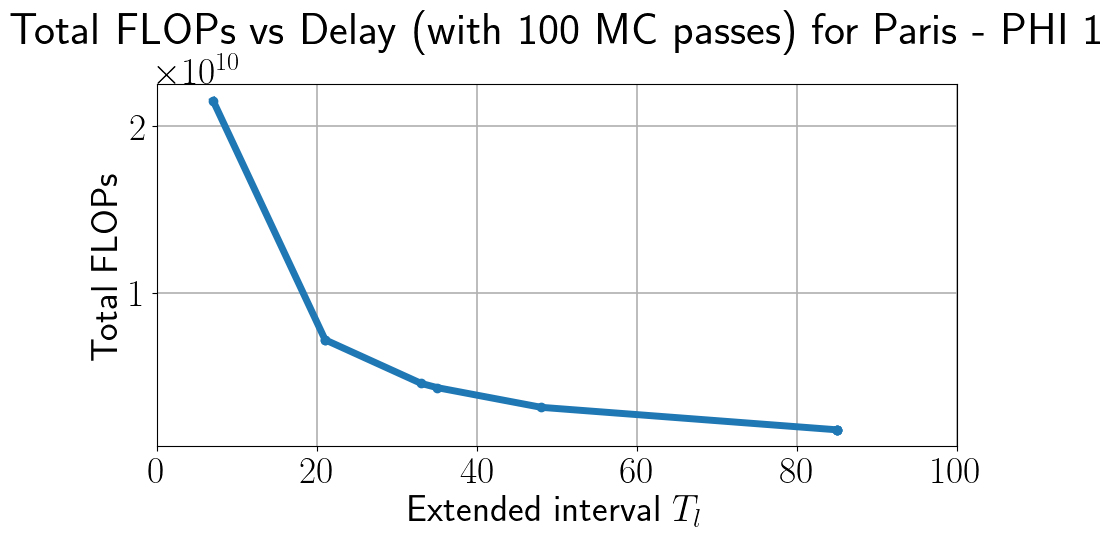

Delay: 7 for phi 10 and eta 1
Total timesteps: 3575
Delay: 7 for phi 10 and eta 2
Total timesteps: 3575
Delay: 21 for phi 10 and eta 10
Total timesteps: 3561
Delay: 21 for phi 10 and eta 20
Total timesteps: 3561
Delay: 21 for phi 10 and eta 30
Total timesteps: 3561
Delay: 21 for phi 10 and eta 40
Total timesteps: 3561
Delay: 21 for phi 10 and eta 50
Total timesteps: 3561
Delay: 85 for phi 10 and eta 70
Total timesteps: 3497
Delay: 85 for phi 10 and eta 90
Total timesteps: 3497
Delay: 85 for phi 10 and eta 100
Total timesteps: 3497


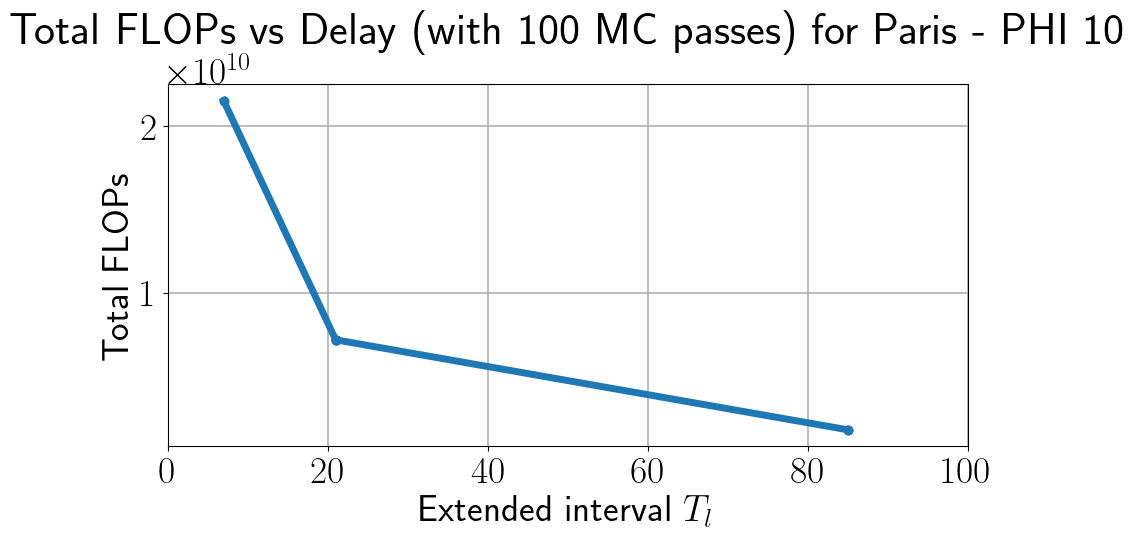

In [8]:

################################################# LOAD AZTEC DATA #################################################

results_path = 'Results_Optimal_Cities_test_kr_ki_new'

cities = ['Paris']

Phis = [0.1,0.5,1,10]
# Phis = [0.1]
ETAS =[1,2,10,20,30,40,50,70,90,100]

# Alphas = [2,3,5]
Alphas = [2]

ppf_static = 0.99
ppf_helper = 0.7


num_services = 5


# Constants

LOOKBACK = 6
LSTM_UNITS = 128
DENSE1_UNITS = 64
OUTPUT_UNITS = 5
MC_PASSES = 100



flops_per_sample = compute_flops_per_sample_block1(
                T=LOOKBACK,
                d=FEATURES,
                h=LSTM_UNITS,
                dense1=DENSE1_UNITS,
                out=OUTPUT_UNITS
            )



delays_all = np.zeros(( len(Phis), len(ETAS)))
flops_all = np.zeros((len(Phis), len(ETAS)))


for city in cities:
    for i,phi in enumerate(Phis): ### Columns
        delays = []
        samples = []
        flops_total = []    
        for k,eta in enumerate(ETAS):
            delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
            delays.append(delay)
            print(f'Delay: {delay} for phi {phi} and eta {eta}')
            for j,alpha in enumerate(Alphas): ### Rows
              
                test_length=fun_test_index_start(city,delay)
                TOTAL_TIMESTEPS = test_length
                print(f'Total timesteps: {TOTAL_TIMESTEPS}')
                FEATURES = 5

                



                num_samples = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, delay)
                total_flops = num_samples * flops_per_sample * MC_PASSES
                samples.append(delay)
                flops_total.append(total_flops)
                delays_all[i,k] = delay
                flops_all[i,k] = total_flops
        plt.figure(figsize=(10, 6))
        plt.plot(delays, flops_total, marker='o')
        plt.title(f'Total FLOPs vs Delay (with 100 MC passes) for {city} - PHI {phi}')
        plt.xlabel(r'Extended interval $T_l$')
        plt.xlim(0, 100)
        plt.ylabel('Total FLOPs')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
               
        
        

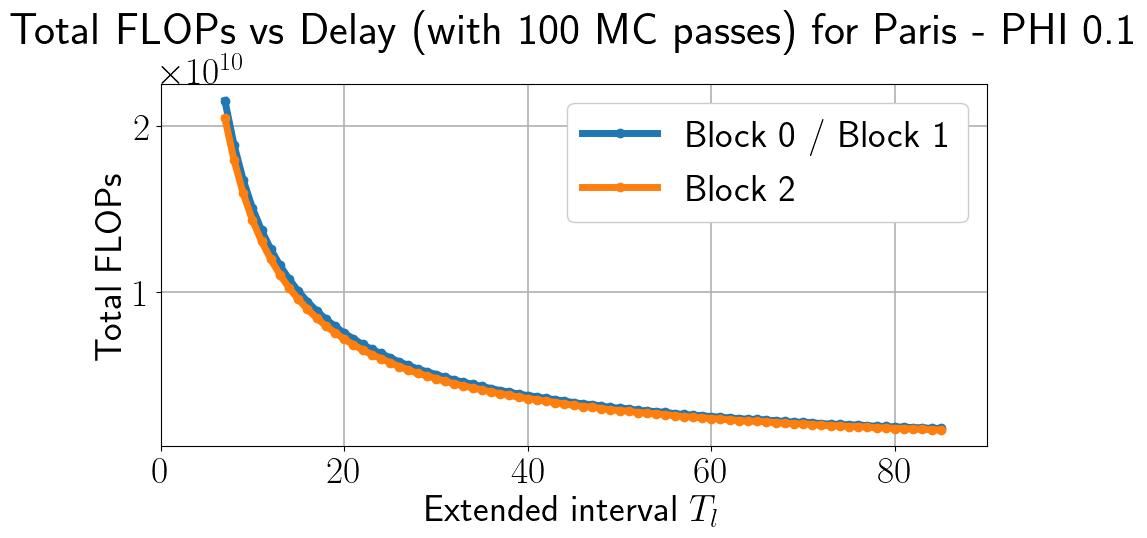

In [9]:

################################################# LOAD AZTEC DATA #################################################

results_path = 'Results_Optimal_Cities_test_kr_ki_new'

cities = ['Paris']

# Phis = [0.1,0.5,1,10]
Phis = [0.1]
# ETAS =[1,2,10,20,30,40,50,70,90,100]
ETAS =[1]

# Alphas = [2,3,5]
Alphas = [2]

ppf_static = 0.99
ppf_helper = 0.7


num_services = 5


# Constants

LOOKBACK = 6
LSTM_UNITS = 128
DENSE1_UNITS = 64
OUTPUT_UNITS = 5
MC_PASSES = 100



def compute_flops_per_sample_block1(T, d, h, dense1, out):
    # LSTM FLOPs: T * (4dh + 4h^2 + 8h)
    lstm_flops = T * (4 * d * h + 4 * h**2 + 8 * h)
    # Dense + ReLU + Output layer FLOPs
    dense_flops = h * dense1 + dense1 + dense1 * out + out
    return lstm_flops + dense_flops

def compute_num_samples(total_timesteps, lookback, delay):
    usable_steps = total_timesteps - delay
    if usable_steps < lookback:
        return 0
    return (usable_steps - lookback) // delay + 1

flops_per_sample_block_1 = compute_flops_per_sample_block1(
    T=LOOKBACK,
    d=FEATURES,
    h=LSTM_UNITS,
    dense1=DENSE1_UNITS,
    out=OUTPUT_UNITS
)


# Example usage
lookback = 6
input_dim = 1
hidden_dim = 128
output_dim = 1

def compute_flops_per_sample_block2(T, d, h, d2):
    """
    Compute total FLOPs for make_model_lstm_block2.
    
    Args:
        T (int): Lookback (sequence length)
        d (int): Input dimension (features)
        h (int): LSTM hidden size
        d2 (int): Output size (final Dense layer)
        n_samples (int): Number of input sequences
        mc_passes (int): Number of Monte Carlo forward passes
        
    Returns:
        Total FLOPs (int)
    """
    # LSTM layer FLOPs
    flops_lstm = T * (4 * d * h + 4 * h ** 2 + 8 * h)
    
    # Dense layer FLOPs
    flops_dense = h * d2 + d2

    # Total per-sample
    flops_per_sample = flops_lstm + flops_dense

   
    return flops_per_sample

flops_per_sample_block_2 = compute_flops_per_sample_block2(
    T=lookback,
    d=input_dim,
    h=hidden_dim,
    d2=output_dim,
)



delays_all = np.zeros(( len(Phis), len(ETAS)))
flops_all = np.zeros((len(Phis), len(ETAS)))

delays_range = range(7, 86)

flops_total_block1=[]
flops_total_block2=[]

for city in cities:
    for i,phi in enumerate(Phis): ### Columns
        delays = []
        samples = []
        flops_total = []    
        for k,eta in enumerate(ETAS):
            # delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
            
            for delay in delays_range:
                delays.append(delay)    
                # print(f'Delay: {delay} for phi {phi} and eta {eta}')
                for j,alpha in enumerate(Alphas): ### Rows
                
                    test_length=fun_test_index_start(city,delay)
                    TOTAL_TIMESTEPS = test_length
                    # print(f'Total timesteps: {TOTAL_TIMESTEPS}')
                    FEATURES = 5

                    



                    # num_samples = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, delay)
                    # total_flops = (num_samples * flops_per_sample * MC_PASSES) / test_length
                    # samples.append(delay)
                    # flops_total.append(total_flops)
                    # delays_all[i,k] = delay
                    # flops_all[i,k] = total_flops
                    
                    num_samples = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, delay)
                    total_flops_block_1 = (num_samples * flops_per_sample_block_1 * MC_PASSES) 
                    total_flops_block_2 = (num_samples * flops_per_sample_block_2 * MC_PASSES) 
                    samples.append(delay)
                    flops_total_block1.append(total_flops_block_1)
                    flops_total_block2.append(total_flops_block_2)
        # Plotting
        # Plotting


        plt.figure(figsize=(10, 6))
        plt.plot(delays, flops_total_block1, marker='o', label='Block 0 / Block 1')
        plt.plot(delays, flops_total_block2, marker='o', label='Block 2')
        plt.title(f'Total FLOPs vs Delay (with 100 MC passes) for {city} - PHI {phi}')
        plt.xlabel(r'Extended interval $T_l$')
        plt.xlim(0, 90)
        plt.ylabel('Total FLOPs')
        plt.grid(True)
        plt.tight_layout()
        
        plt.legend()
               
        
        

In [10]:
aaa= pd.read_csv('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/FLOPS/Elapsed_time_estimated_flops.csv',index_col=0)

In [12]:
aaa.iloc[1,1]

18750000.0

In [13]:
aaa

,PHI_0.1,PHI_0.5,PHI_1,PHI_10
Elapsed Time,1.188301e+01,1.729770e+01,8.652210e-04,7.545948e-04
Estimated FLOPs,1.875000e+07,1.875000e+07,1.875000e+07,1.875000e+07
Estimated FLOPs per second,1.577884e+06,1.083959e+06,2.167076e+10,2.484777e+10


In [14]:
flops_block_3 = aaa.iloc[1,1]

In [15]:
block_0_delays = [ random.randint(7,85) for _ in range(9)]
# block_0_delays = sorted(block_0_delays)
# block_0_delays = [7, 10, 20, 30, 40, 50, 60, 70, 80]
block_0_delays.append(delay)
block_0_delays = sorted(block_0_delays)
total_flops_block_0_sum = 0  
for block_0_delay in block_0_delays:
    test_length=fun_test_index_start(city,delay)
    TOTAL_TIMESTEPS = test_length               
    

    num_samples_block_0 = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, block_0_delay)

    total_flops_block_0 = (num_samples_block_0 * flops_per_sample_block_1 * MC_PASSES)
    total_flops_block_0_sum += total_flops_block_0


In [16]:
total_flops_block_0_sum

48806605300

In [17]:
total_flops_block_0_sum = 73358063300

In [18]:
block_0_delays

[10, 11, 30, 58, 60, 60, 62, 70, 71, 85]

In [19]:
total_flops_block_0_sum

73358063300

In [20]:
def total_complexity_fun(delay,flops_block_3,flops_block_0):
    

  
    test_length=fun_test_index_start(city,delay)
    TOTAL_TIMESTEPS = test_length               
    

    num_samples = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, delay)

    total_flops_block_1 = (num_samples * flops_per_sample_block_1 * MC_PASSES)
    total_flops_block_2 = (num_samples * flops_per_sample_block_2 * MC_PASSES) 

    test_length_helper=fun_test_index_start(city,1)
    TOTAL_TIMESTEPS = test_length_helper               
    

    num_samples_helper = compute_num_samples(TOTAL_TIMESTEPS, LOOKBACK, 1)
    total_flops_block_helper = (num_samples_helper * flops_per_sample_block_1 * MC_PASSES)



    helper =  (total_flops_block_helper )
    block_3 = (flops_block_3)
    total_flops_block_0_sum = (flops_block_0)


    total_flops = total_flops_block_0_sum + total_flops_block_1 + total_flops_block_2 + helper + block_3
    return total_flops, total_flops_block_0_sum, total_flops_block_1, total_flops_block_2, helper, block_3



In [21]:
total_complexity= total_complexity_fun(delay,flops_block_3)

TypeError: total_complexity_fun() missing 1 required positional argument: 'flops_block_0'

In [22]:
total_complexity_list=[]
total_flops_block_0_sum_list=[]
total_flops_block_1_list=[]
total_flops_block_2_list=[]
total_flops_helper_list=[]
total_flops_block_3_list=[]


for delay in delays_range:
    total_flops, total_flops_block_0_sum, total_flops_block_1, total_flops_block_2, helper, block_3= total_complexity_fun(delay,flops_block_3,total_flops_block_0_sum)
    total_complexity_list.append(total_flops)
    total_flops_block_0_sum_list.append(total_flops_block_0_sum)
    total_flops_block_1_list.append(total_flops_block_1)
    total_flops_block_2_list.append(total_flops_block_2)
    total_flops_helper_list.append(helper)
    total_flops_block_3_list.append(block_3)

In [23]:
delays_ticks =[7,21,27,33,35,48,85]

ticks = [0,10,20,30,40,50,60,70,80,90]

In [24]:
aa=np.array(total_complexity_list)

In [25]:
aa.shape

(79,)

In [26]:
total_complexity_list[-1]

228092955000.0

In [27]:
[total_complexity_list[delay-7] for delay in delays_ticks]

[266743296600.0,
 238663988600.0,
 235525713000.0,
 233543644200.0,
 233048127000.0,
 230735713400.0,
 228092955000.0]

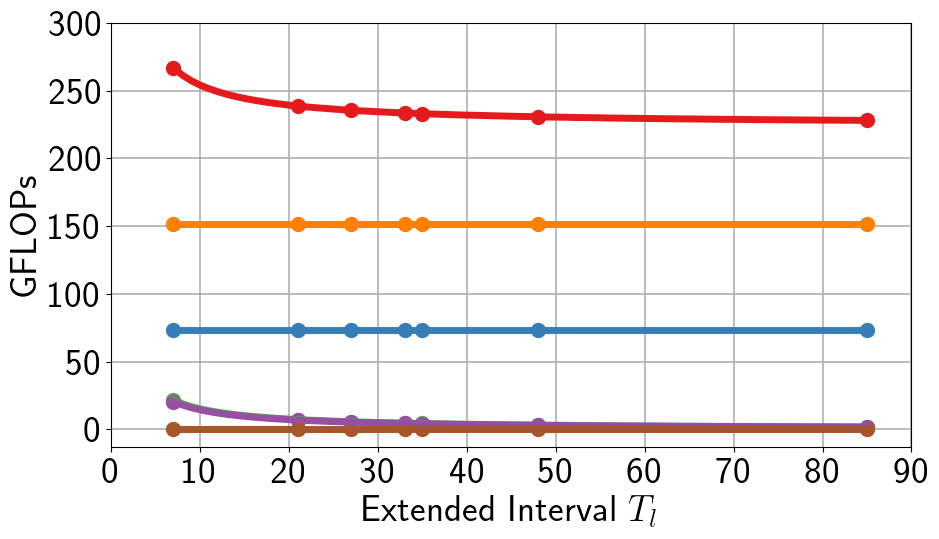

In [47]:
colors = ['#e41a1c',
'#377eb8',
'#4daf4a',
'#984ea3',
'#ff7f00',
'#a65628',
]

plt.figure(figsize=(10, 6))
plt.plot(delays_range, total_complexity_list,  label='Total', color=colors[0])
plt.plot(delays_range, total_flops_block_0_sum_list,  label='Block 0', color=colors[1])
plt.plot(delays_range, total_flops_block_1_list,  label='Block 1', color=colors[2])
plt.plot(delays_range, total_flops_block_2_list,  label='Block 2', color=colors[3])
plt.plot(delays_range, total_flops_block_3_list,  label='Block 3', color=colors[5])
plt.plot(delays_range, total_flops_helper_list,  label='Helper', color=colors[4])
plt.scatter(delays_ticks, [total_complexity_list[delay-7] for delay in delays_ticks], color=colors[0], marker='o', s=100)
plt.scatter(delays_ticks, [total_flops_block_0_sum_list[delay-7] for delay in delays_ticks], color=colors[1], marker='o', s=100)
plt.scatter(delays_ticks, [total_flops_block_1_list[delay-7] for delay in delays_ticks], color=colors[2], marker='o', s=100)
plt.scatter(delays_ticks, [total_flops_block_2_list[delay-7] for delay in delays_ticks], color=colors[3], marker='o', s=100)
plt.scatter(delays_ticks, [total_flops_block_3_list[delay-7] for delay in delays_ticks], color=colors[5], marker='o', s=100)
plt.scatter(delays_ticks, [total_flops_helper_list[delay-7] for delay in delays_ticks], color=colors[4], marker='o', s=100)
# plt.title(r'Total Complexity vs Extended Interval $T_l$')
plt.xlabel(r'Extended Interval $T_l$')
plt.xticks(ticks,ticks)
plt.yticks([0, 5e10, 1e11,1.5e11,2e11,2.5e11,3e11], [0, 50, 100, 150, 200, 250, 300])
plt.ylabel(r'GFLOPs')
plt.xlim(0, 90)
plt.grid(True)
plt.tight_layout()
# plt.legend(ncol=6,bbox_to_anchor=(0.5, 1.1), loc='upper center')

# plt.savefig(f'Total_complexity_vs_delay_{city}.pdf')

In [28]:
delays_stacked_bar= [ 7,15,21,48,85]

In [29]:
def select_values_from_delays(delays, values):
    selected_values = []
    for delay in delays:
        
        selected_values.append(values[delay-7])
    return selected_values

In [30]:
total_flops_block_0_sum_list_stacked = select_values_from_delays(delays_stacked_bar, total_flops_block_0_sum_list)
total_flops_block_1_list_stacked = select_values_from_delays(delays_stacked_bar, total_flops_block_1_list)
total_flops_block_2_list_stacked = select_values_from_delays(delays_stacked_bar, total_flops_block_2_list)
total_flops_block_3_list_stacked = select_values_from_delays(delays_stacked_bar, total_flops_block_3_list)
total_flops_helper_list_stacked = select_values_from_delays(delays_stacked_bar, total_flops_helper_list)


In [31]:
x_axes_delays = [10,20,30,40,50]

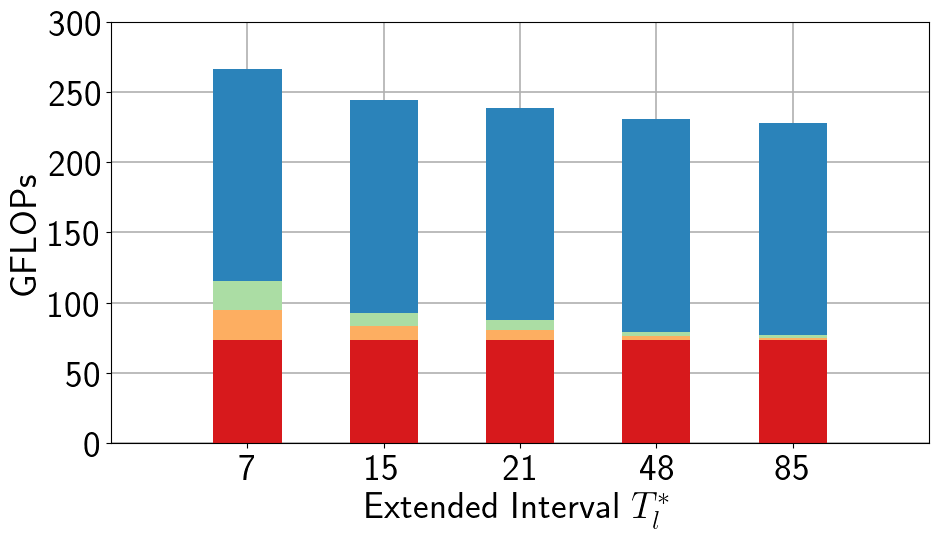

In [41]:
### make a plot of stacked bars with the total complexity and the different blocks witth stacked lists
plt.figure(figsize=(10, 6))
width = 5
# colors = ['',
#     '#d7191c',
# '#fdae61',
# '#ffffbf',
# '#abd9e9',
# '#2c7bb6'
# ]

colors = [''
    ,'#d7191c',
                  '#fdae61',
                  '#abdda4',
                  '#2b83ba',
                  '#a65628']

#create a list of 5 different hatches
hatches = ['/', '\\', '|', '-', '+']


bar1 = plt.bar(x_axes_delays, total_flops_block_0_sum_list_stacked, width, label='Block 0', color=colors[1])
bar2 = plt.bar(x_axes_delays, total_flops_block_1_list_stacked, width, bottom=total_flops_block_0_sum_list_stacked, label='Block 1', color=colors[2])
bar3 = plt.bar(x_axes_delays, total_flops_block_2_list_stacked, width, bottom=np.array(total_flops_block_0_sum_list_stacked) + np.array(total_flops_block_1_list_stacked), label='Block 2', color=colors[3])
bar4 = plt.bar(x_axes_delays, total_flops_block_3_list_stacked, width, bottom=np.array(total_flops_block_0_sum_list_stacked) + np.array(total_flops_block_1_list_stacked) + np.array(total_flops_block_2_list_stacked), label='Block 3', color=colors[5])
bar5 = plt.bar(x_axes_delays, total_flops_helper_list_stacked, width, bottom=np.array(total_flops_block_0_sum_list_stacked) + np.array(total_flops_block_1_list_stacked) + np.array(total_flops_block_2_list_stacked) + np.array(total_flops_block_3_list_stacked), label='Helper', color=colors[4])

# plt.title(r'Total Complexity vs Extended Interval $T_l$')
plt.xlabel(r'Extended Interval $T_l^*$')
plt.xticks(x_axes_delays, delays_stacked_bar)
plt.yticks([0, 5e10, 1e11,1.5e11,2e11,2.5e11,3e11], [0, 50, 100, 150, 200, 250, 300])
plt.ylabel(r'GFLOPs')
plt.xlim(0, 60)
plt.grid('y')
plt.tight_layout()

### new is because we changed the colros of the bars
# plt.legend(ncol = 5, bbox_to_anchor=(0.5, 1.1), loc='upper center')
# plt.savefig(f'Total_complexity_vs_delay_stacked_{city}.pdf_new')
plt.savefig(f'Total_complexity_vs_delay_stacked_{city}_equally_spaced_new.pdf')

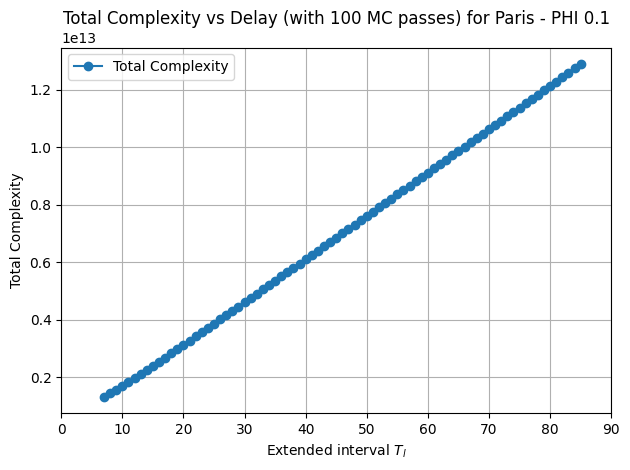

In [34]:
plt.plot(delays_range, total_complexity_list, marker='o', label='Total Complexity')
plt.title(f'Total Complexity vs Delay (with 100 MC passes) for {city} - PHI {phi}')
plt.xlabel(r'Extended interval $T_l$')
plt.xlim(0, 90)
plt.ylabel('Total Complexity')
plt.grid(True)
plt.tight_layout()
plt.legend()

In [23]:
total_complexity

12885394262700.0

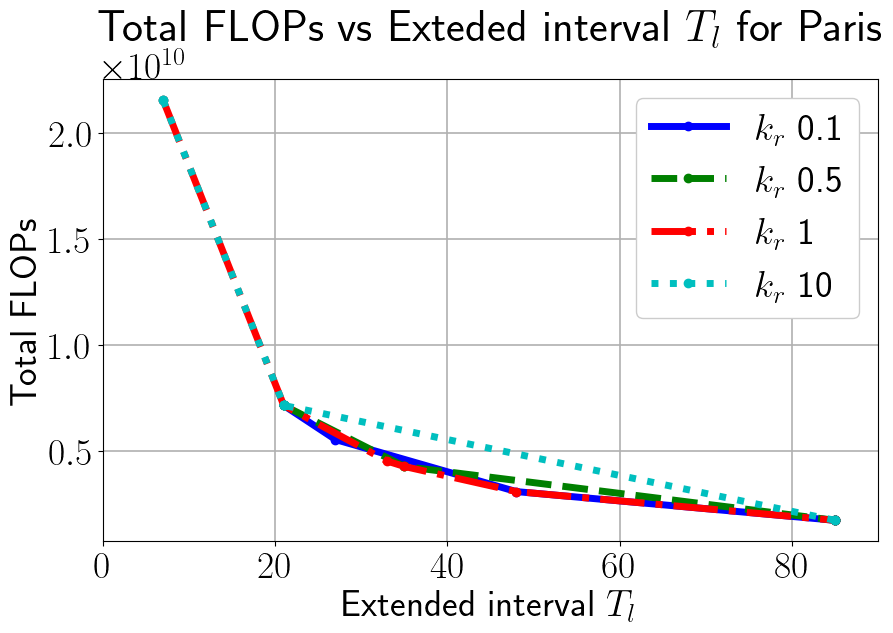

In [44]:
linestyles = ['-', '--', '-.', ':']
colors = ['b', 'g', 'r', 'c']
plt.figure(figsize=(10, 6))
for i,phi in enumerate(Phis):
    plt.plot(delays_all[i],flops_all[i],label=f'$k_r$ {phi}', linestyle=linestyles[i], color=colors[i], marker='o')
plt.title(f'Total FLOPs vs Exteded interval $T_l$ for {city}')
plt.xlabel(r'Extended interval $T_l$')
plt.xlim(0, 90)
plt.ylabel('Total FLOPs')
plt.legend()
plt.grid(True)


In [ ]:
clrs = ['#e41a1c',
'#377eb8',
'#4daf4a',
'#984ea3',
'#ff7f00',
'#a65628',
]
lbs = ['Total','Block 0','Block 1','Block 2','Block 3','Helper']
linestyles = ['-', '--', '-.', (5,(10,3))]

fig, ax = plt.subplots(figsize =(20,20))
legend_1_entries = [plt.Line2D([0], [0], color=clrs[0], lw=2, label=lbs[0]),
                        plt.Line2D([0], [0], color=clrs[1], lw=2, label=lbs[1]),
                        plt.Line2D([0], [0], color=clrs[2], lw=2, label=lbs[2]),
                        plt.Line2D([0], [0], color=clrs[3], lw=2, label=lbs[3]),
                        plt.Line2D([0], [0], color=clrs[5], lw=2,  label=lbs[4]),
                        plt.Line2D([0], [0], color=clrs[4], lw=2,  label=lbs[5])]
# legend_2_entries = [plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[0], label=r'$k_r = 0.1$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[1], label=r'$k_r = 0.5$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle =linestyles[2], label=r'$k_r = 1$'),
#                         plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[3], label=r'$k_r = 10$')]

first_legend = ax.legend(handles=legend_1_entries,loc='upper left',fontsize=50,ncol=6,bbox_to_anchor=(0.1, 0.89),frameon = False)
ax.add_artist(first_legend)
# ax.legend(handles=legend_2_entries,loc='upper left',fontsize='large',ncol=4,bbox_to_anchor=(0.1, 0.85))
ax.axis('off')
fig.canvas.draw()
bbox = first_legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())




fig.savefig('LEGEND_FLOPS.png', dpi=300, bbox_inches='tight')
fig.savefig('LEGEND_FLOPS.pdf', dpi=300, bbox_inches='tight')
fig.tight_layout()

In [34]:
import matplotlib.patches as mpatches

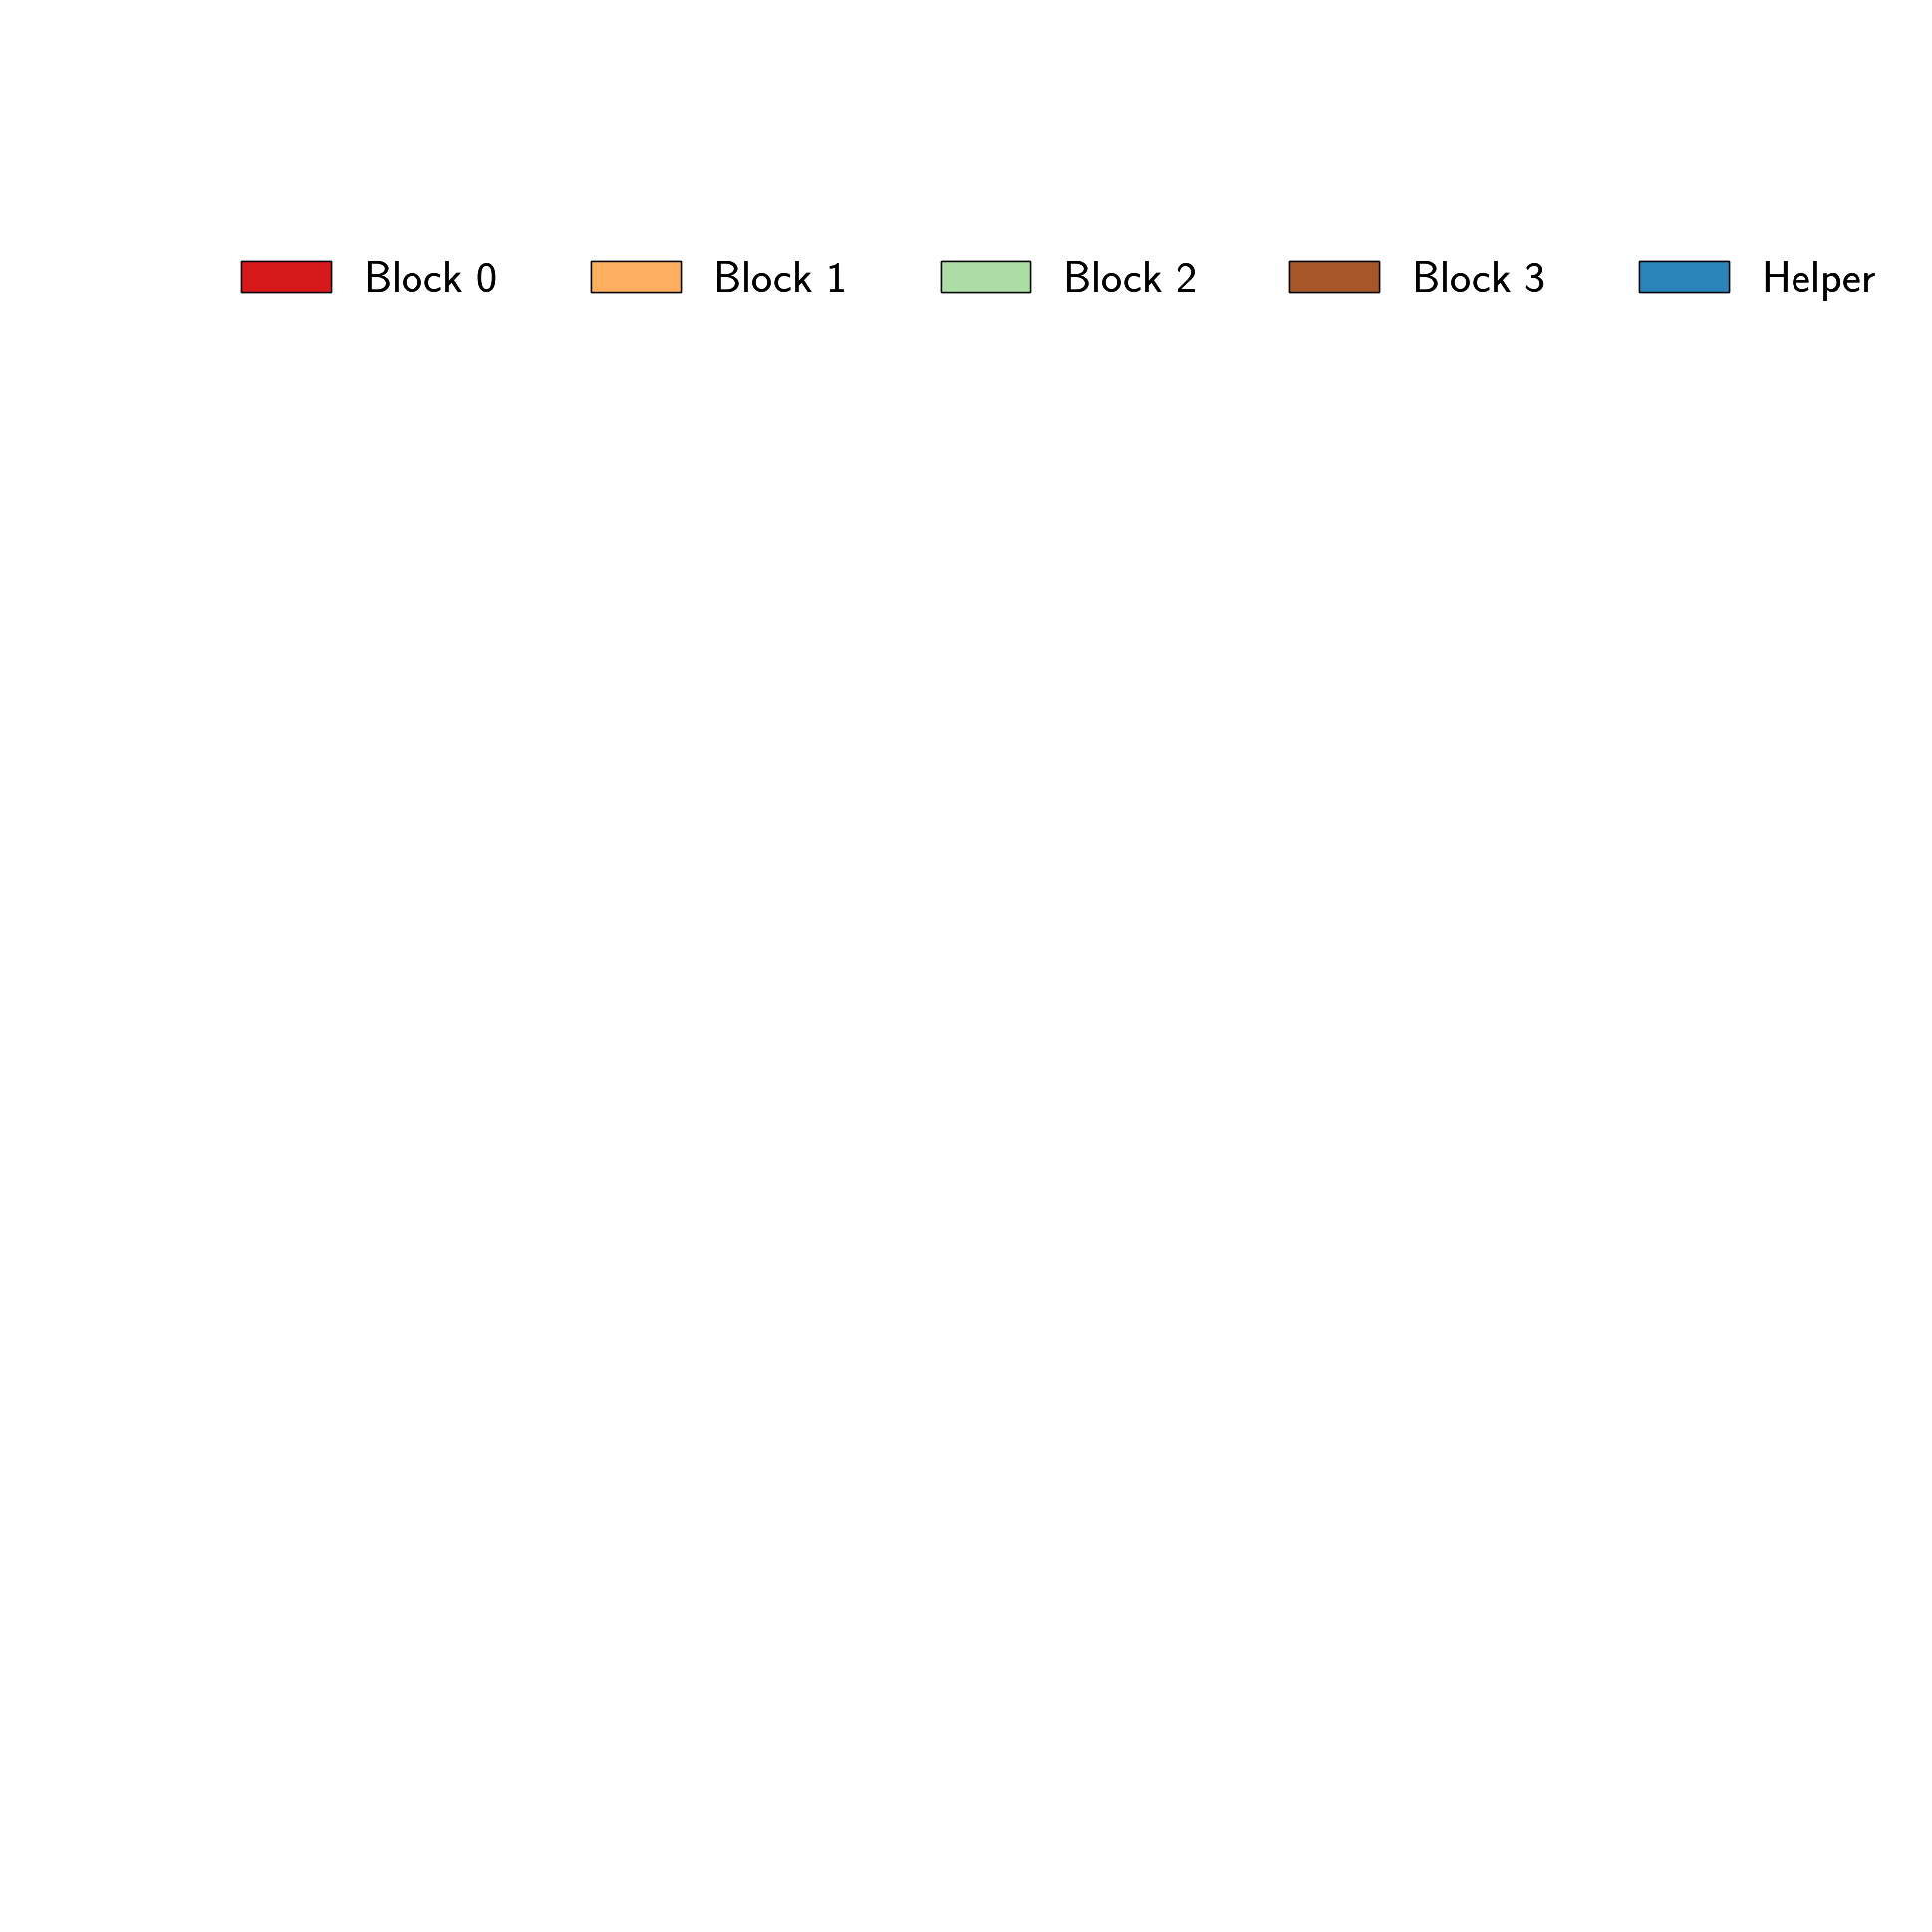

In [39]:
# clrs = [
# '#377eb8',
# '#4daf4a',
# '#984ea3',
# '#ff7f00',
# '#a65628',
# ]

clrs = ['#d7191c'
    ,'#fdae61',
                  '#abdda4',
                  '#2b83ba',
                  '#a65628',
                  '#a65628']
lbs = ['Block 0','Block 1','Block 2','Block 3','Helper']


fig, ax = plt.subplots(figsize =(20,20))
              

legend_handles = [mpatches.Patch(facecolor=clrs[0], edgecolor='black', label=lbs[0]),
                    mpatches.Patch(facecolor=clrs[1], edgecolor='black', label=lbs[1]),
                    mpatches.Patch(facecolor=clrs[2], edgecolor='black', label=lbs[2]),
                    mpatches.Patch(facecolor=clrs[4], edgecolor='black', label=lbs[3]),
                    mpatches.Patch(facecolor=clrs[3], edgecolor='black', label=lbs[4])
                    
             ]
# ax.legend(legend_handles, ['AZTEC+','AZTEC','Deepcog', 'Exp_Smoothing'],fontsize='large')

first_legend = ax.legend(handles=legend_handles,loc='upper left',fontsize='large',ncol=5,bbox_to_anchor=(0.1, 0.89),frameon = False)
ax.add_artist(first_legend)
# ax.legend(handles=legend_2_entries,loc='upper left',fontsize='large',ncol=4,bbox_to_anchor=(0.1, 0.85))
ax.axis('off')
fig.canvas.draw()
bbox = first_legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())




fig.savefig('LEGEND_FLOPS_STACKED_new.png', dpi=300, bbox_inches='tight')
fig.savefig('LEGEND_FLOPS_STACKED_new.pdf', dpi=300, bbox_inches='tight')
fig.tight_layout()